In [9]:
import os
import pickle
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, Add, Reshape
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

save_path = '/content/drive/MyDrive/image_caption_generator'

with open(os.path.join(save_path, 'features.pkl'), 'rb') as f:
    features = pickle.load(f)
with open(os.path.join(save_path, 'tokenizer.pkl'), 'rb') as f:
    tokenizer = pickle.load(f)
df = pd.read_csv(os.path.join(save_path, 'cleaned_captions.csv'))

print(f"Features: {len(features)} images")
print(f"Captions: {len(df)}")
print("Setup complete!")

Mounted at /content/drive
Features: 8091 images
Captions: 40455
Setup complete!


In [10]:
# parameters
vocab_size = len(tokenizer.word_index) + 1
max_length = max(len(c.split()) for c in df['caption'].tolist())
embedding_dim = 256
units = 256
batch_size = 64

print(f"Vocab size: {vocab_size}")
print(f"Max length: {max_length}")

# Group captions by image
image_captions = {}
for _, row in df.iterrows():
    img = row['image']
    cap = row['caption']
    if img not in image_captions:
        image_captions[img] = []
    image_captions[img].append(cap)

all_images = list(image_captions.keys())
train_images = all_images[:6000]
test_images  = all_images[6000:]
print(f"Train: {len(train_images)} | Test: {len(test_images)}")

Vocab size: 8781
Max length: 37
Train: 6000 | Test: 2091


In [11]:
# Prepare data
print("Preparing training data...")

# Use 2000 images — safe for free Colab RAM
selected_images = train_images[:2000]

X1, X2, y = [], [], []

for img_name in selected_images:
    if img_name not in features:
        continue
    feat = features[img_name][0]
    for cap in image_captions[img_name]:
        seq = tokenizer.texts_to_sequences([cap])[0]
        for t in range(1, len(seq)):
            in_seq = pad_sequences([seq[:t]], maxlen=max_length)[0]
            # No one-hot encoding! Just the word index number
            out_word = seq[t]
            X1.append(feat)
            X2.append(in_seq)
            y.append(out_word)

X1 = np.array(X1, dtype=np.float32)
X2 = np.array(X2, dtype=np.float32)
y  = np.array(y,  dtype=np.int32)

print(f"X1 shape: {X1.shape}")
print(f"X2 shape: {X2.shape}")
print(f"y  shape: {y.shape}")

ram = (X1.nbytes + X2.nbytes + y.nbytes) / 1024 / 1024
print(f"Total RAM used: {ram:.0f} MB")
print("Data ready!")

Preparing training data...
X1 shape: (119109, 2048)
X2 shape: (119109, 37)
y  shape: (119109,)
Total RAM used: 948 MB
Data ready!


In [14]:
def build_model(vocab_size, max_length, embedding_dim, units):
    image_input = Input(shape=(2048,), name='image_input')
    image_dense = Dense(units, activation='relu')(image_input)
    image_reshape = Reshape((1, units))(image_dense)

    caption_input = Input(shape=(max_length,), name='caption_input')
    # Removed mask_zero=True — this was causing the error!
    caption_embed = Embedding(
        vocab_size, embedding_dim
    )(caption_input)
    caption_lstm = LSTM(units, return_sequences=True)(caption_embed)

    combined = Add()([image_reshape, caption_lstm])
    combined_lstm = LSTM(units)(combined)
    combined_dropout = Dropout(0.5)(combined_lstm)
    output = Dense(vocab_size, activation='softmax')(combined_dropout)

    model = Model(
        inputs=[image_input, caption_input],
        outputs=output
    )
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return model

model = build_model(vocab_size, max_length, embedding_dim, units)
print("Model built successfully!")
model.summary()

Model built successfully!


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ caption_input       │ (None, 37)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │    524,544 │ image_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 37, 256)   │  2,247,936 │ caption_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 1, 256)    │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_4 (LSTM)       │ (None, 37, 256)   │    525,312 │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 37, 256)   │          0 │ reshape_2[0][0],  │
│                     │                   │            │ lstm_4[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_5 (LSTM)       │ (None, 256)       │    525,312 │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ lstm_5[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 8781)      │  2,256,717 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,079,821 (23.19 MB)

 Trainable params: 6,079,821 (23.19 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Train
checkpoint_path = os.path.join(save_path, 'best_model.keras')

callbacks = [
    ModelCheckpoint(
        checkpoint_path,
        monitor='loss',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='loss',
        patience=3,
        verbose=1
    )
]

print("Starting training...")
print("-" * 50)

history = model.fit(
    [X1, X2],
    y,
    epochs=20,
    batch_size=batch_size,
    callbacks=callbacks,
    verbose=1
)

print("Training complete!")

Starting training...
--------------------------------------------------
Epoch 1/20
1861/1862 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.1347 - loss: 5.7375
Epoch 1: loss improved from None to 5.37559, saving model to /content/drive/MyDrive/image_caption_generator/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/image_caption_generator/best_model.keras
1862/1862 ━━━━━━━━━━━━━━━━━━━━ 36s 17ms/step - accuracy: 0.1613 - loss: 5.3756
Epoch 2/20
1860/1862 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2732 - loss: 4.3644
Epoch 2: loss improved from 5.37559 to 4.21968, saving model to /content/drive/MyDrive/image_caption_generator/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/image_caption_generator/best_model.keras
1862/1862 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - accuracy: 0.2873 - loss: 4.2197
Epoch 3/20
1862/1862 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3169 - loss: 3.8492
Epoch 3: loss improved from 4.21968 to 3.81044, savi

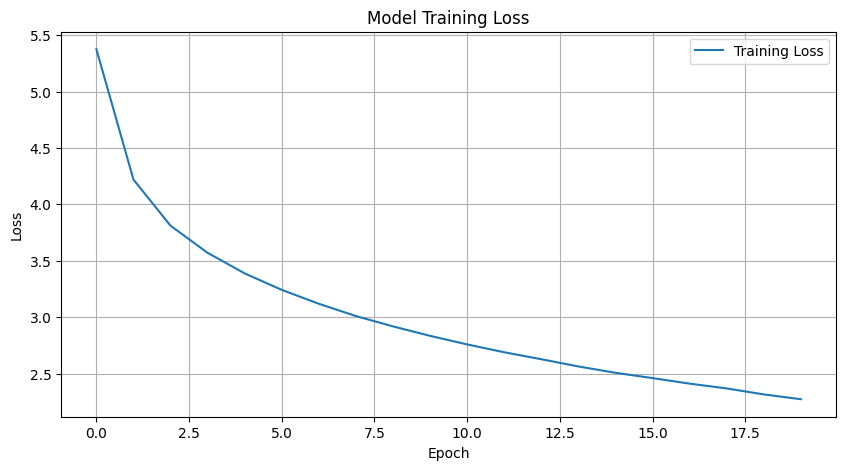

Done!


In [16]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.title('Model Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig('training_loss.png')
plt.show()
print("Done!")